# ViGoEmotions Code-Switching Analysis

Notebook này phân tích mức độ code-switching trong ViGoEmotions trước khi huấn luyện các mô hình như XLM-R + xLSTM.

Mục tiêu:
- Đọc dữ liệu ViGoEmotions từ Excel/CSV/Pickle.
- Gắn cờ comment có English token, teencode/slang, emoji, URL/mention/hashtag.
- Tạo nhãn `cs_group`: `pure_vi`, `english_mixed`, `teencode_slang`, `emoji_only`, `other_noise`.
- Thống kê phân bố code-switching theo split và theo emotion label.
- Xuất file CSV để dùng cho báo cáo và để chia subset khi evaluate baseline/model mới.


In [1]:
import ast
import json
import os
import pickle
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from datasets import load_dataset
except ImportError:
    load_dataset = None

pd.set_option('display.max_colwidth', 160)
pd.set_option('display.max_columns', 80)


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cấu hình nguồn dữ liệu

Mặc định notebook tải trực tiếp ViGoEmotions từ Hugging Face bằng `datasets.load_dataset`.

Vì ViGoEmotions là gated dataset, bạn cần được cấp quyền và đã login Hugging Face trước khi chạy:

```bash
huggingface-cli login
```

Nếu muốn dùng file local, đặt `USE_HF_DATASET = False` và sửa `DATA_PATH`.

Notebook hỗ trợ:
- Hugging Face dataset: `uitnlp/vigoemotions`.
- `.xlsx`: có sheet `train`, `val`/`dev`, `test`.
- `.csv`: có cột `text`, `labels`, và có thể có cột `set`/`split`.
- `.pkl`: tuple `(train_df, val_df, test_df)` giống các notebook `_s3`.

In [2]:
USE_HF_DATASET = True
HF_DATASET_NAME = 'uitnlp/vigoemotions'

# Chỉ dùng khi USE_HF_DATASET = False
DATA_PATH = None

# Nếu chạy local và có file khác, ví dụ:
# DATA_PATH = '/Users/nhule/Desktop/KLTN/ViGoEmotions/corpus/dataset_V1.xlsx'
# DATA_PATH = '/Users/nhule/Desktop/KLTN/ViGoEmotions/corpus/s3_normalized_train-val-test.pkl'

OUT_DIR = 'outputs_code_switching'
os.makedirs(OUT_DIR, exist_ok=True)

HF_DATASET_NAME if USE_HF_DATASET else DATA_PATH

'uitnlp/vigoemotions'

In [3]:
def normalize_hf_split(split_name):
    name = str(split_name).lower()
    if name in ['validation', 'valid', 'dev']:
        return 'val'
    return name


def load_vigoemotions_from_hf(dataset_name='uitnlp/vigoemotions'):
    if load_dataset is None:
        raise ImportError(
            "Chưa cài package `datasets`. Hãy chạy `pip install datasets` "
            "hoặc đặt USE_HF_DATASET = False để đọc file local."
        )
    try:
        ds = load_dataset(dataset_name)
    except Exception as exc:
        raise RuntimeError(
            "Không tải được ViGoEmotions từ Hugging Face. Nếu dataset gated, hãy kiểm tra bạn đã được cấp quyền "
            "và đã login bằng `huggingface-cli login`. Lỗi gốc: " + str(exc)
        ) from exc

    frames = []
    for split_name, split_data in ds.items():
        part = split_data.to_pandas()
        part['split'] = normalize_hf_split(split_name)
        frames.append(part)

    df = pd.concat(frames, ignore_index=True)
    if 'label' in df.columns and 'labels' not in df.columns:
        df = df.rename(columns={'label': 'labels'})
    return df


def load_vigoemotions_from_file(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in ['.xlsx', '.xls']:
        xls = pd.ExcelFile(path)
        sheet_map = {s.lower(): s for s in xls.sheet_names}
        train_df = pd.read_excel(path, sheet_name=sheet_map.get('train', xls.sheet_names[0]))
        val_name = sheet_map.get('val') or sheet_map.get('dev') or sheet_map.get('validation')
        test_name = sheet_map.get('test')
        val_df = pd.read_excel(path, sheet_name=val_name) if val_name else pd.DataFrame()
        test_df = pd.read_excel(path, sheet_name=test_name) if test_name else pd.DataFrame()
        train_df['split'] = 'train'
        val_df['split'] = 'val'
        test_df['split'] = 'test'
        return pd.concat([train_df, val_df, test_df], ignore_index=True)

    if ext == '.csv':
        df = pd.read_csv(path)
        if 'split' not in df.columns and 'set' in df.columns:
            df = df.rename(columns={'set': 'split'})
        if 'split' not in df.columns:
            df['split'] = 'unknown'
        return df

    if ext in ['.pkl', '.pickle']:
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        if isinstance(obj, tuple) and len(obj) == 3:
            train_df, val_df, test_df = obj
            train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()
            train_df['split'] = 'train'; val_df['split'] = 'val'; test_df['split'] = 'test'
            return pd.concat([train_df, val_df, test_df], ignore_index=True)
        if isinstance(obj, pd.DataFrame):
            df = obj.copy()
            if 'split' not in df.columns:
                df['split'] = 'unknown'
            return df
        raise ValueError('Unsupported pickle format')

    raise ValueError(f'Unsupported file extension: {ext}')


if USE_HF_DATASET:
    df = load_vigoemotions_from_hf(HF_DATASET_NAME)
else:
    if DATA_PATH is None:
        raise ValueError('DATA_PATH must be set when USE_HF_DATASET = False')
    df = load_vigoemotions_from_file(DATA_PATH)

df.head()

,id,text,labels,split
0,tik000008,Xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng,[12],train
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]",train
2,32895,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố làm to","[8, 7]",train
3,you001182,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi, 1 nếm<br>2: tư duy 3%<br>3: Phương pháp thở",[27],train
4,12052,"Dima Egiazarov bởi vì chúng tôi là người Việt Nam, còn hiểu hay không thì kệ mẹ bạn","[24, 23]",train


In [4]:
print(df.shape)
print(df.columns.tolist())
display(df['split'].value_counts(dropna=False))
display(df[['split', 'text', 'labels']].head())

(20664, 4)
['id', 'text', 'labels', 'split']


split
train    16531
test      2067
val       2066
Name: count, dtype: int64

,split,text,labels
0,train,Xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng,[12]
1,train,bức ảnh xuất sắc ❤️,"[2, 8, 3]"
2,train,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố làm to","[8, 7]"
3,train,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi, 1 nếm<br>2: tư duy 3%<br>3: Phương pháp thở",[27]
4,train,"Dima Egiazarov bởi vì chúng tôi là người Việt Nam, còn hiểu hay không thì kệ mẹ bạn","[24, 23]"


## 2. Detector code-switching dạng rule-based

Đây là detector phục vụ phân tích thực nghiệm, không phải gold annotation. Ta dùng nó để chia subset và so sánh model.

In [5]:
URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'(?<!\w)@[\w_]+')
HASHTAG_RE = re.compile(r'(?<!\w)#[\w_]+')
TOKEN_RE = re.compile(r"[A-Za-zÀ-ỹĐđ]+(?:[-'][A-Za-zÀ-ỹĐđ]+)?|\d+|[^\w\s]", re.UNICODE)
ASCII_ALPHA_RE = re.compile(r'^[A-Za-z]+$')
VIET_CHARS_RE = re.compile(r'[ăâđêôơưáàảãạấầẩẫậắằẳẵặéèẻẽẹếềểễệíìỉĩịóòỏõọốồổỗộớờởỡợúùủũụứừửữựýỳỷỹỵ]', re.IGNORECASE)
EMOJI_RE = re.compile('[\U0001F300-\U0001FAFF\U00002700-\U000027BF\U00002600-\U000026FF]+')

VI_STOPWORDS_ASCII = set('''
toi tui tao may ban minh minh ban la thi ma va hay nhung vi voi cho cua trong tren duoi nay kia do day roi chua khong ko k k0
duoc dc dk di den ve an uong lam hoc choi xem nghe noi nghi biet thay thich yeu ghe qua qua troi rat hoi qua lam luon nua
nguoi nha ong ba anh chi em con cai thang nho no minh chung minh chung ta cac nhieu it mot hai ba bon nam sau bay tam chin muoi
'''.split())

EN_COMMON = set('''
love like hate happy sad angry fear sorry thanks thank please ok okay yes no good bad best worst cute nice cool hot trend trending fan idol team
movie music video clip live stream comment share post status story drama fake real toxic cringe brainwash anti respect support follow unfollow block
game gaming win lose loser boy girl baby bro sis friend family crush deadline job work school class online offline ship couple
'''.split())

TEENCODE = set('''
ko k khong hok hong hông hem dc dk đc đk j z dz zj zi zì v vl vcl vc clm cmm đm dm đcm dcm đjt dit
thik thich iu yeu lun luon rùi roi ròi mik mình mềnh mng mn ngta người_ta ny crush kb ib rep cmt tks thanks pls plz
bt bth bthuong qá quá qa wa wá vs với cx cũng cg cũng chứ chz jz zậy vạy zay vãi vaii vkl
'''.split())

def tokenize(text):
    return TOKEN_RE.findall(str(text))

def parse_labels(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    s = str(value)
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass
    return [x.strip() for x in s.strip('[]').replace('"', '').replace("'", '').split(',') if x.strip()]

def is_english_like(token):
    t = token.lower()
    if not ASCII_ALPHA_RE.match(token):
        return False
    if len(t) <= 2:
        return False
    if t in VI_STOPWORDS_ASCII or t in TEENCODE:
        return False
    if t in EN_COMMON:
        return True
    # Heuristic: ASCII word with common English suffix/shape and not common Vietnamese no-accent word.
    return bool(re.search(r'(ing|tion|ment|ness|ous|ive|er|ed|ly|ship|ful)$', t))

def analyze_text(text):
    raw = str(text)
    tokens = tokenize(raw)
    word_tokens = [tok for tok in tokens if re.search(r'[A-Za-zÀ-ỹĐđ]', tok)]
    lower_words = [tok.lower() for tok in word_tokens]
    english_tokens = [tok for tok in word_tokens if is_english_like(tok)]
    teencode_tokens = [tok for tok in lower_words if tok in TEENCODE]
    has_vietnamese_diacritic = bool(VIET_CHARS_RE.search(raw))
    emoji_count = len(EMOJI_RE.findall(raw))
    url_count = len(URL_RE.findall(raw))
    mention_count = len(MENTION_RE.findall(raw))
    hashtag_count = len(HASHTAG_RE.findall(raw))
    english_ratio = len(english_tokens) / max(len(word_tokens), 1)
    teencode_ratio = len(teencode_tokens) / max(len(word_tokens), 1)

    if english_tokens:
        cs_group = 'english_mixed'
    elif teencode_tokens:
        cs_group = 'teencode_slang'
    elif emoji_count > 0:
        cs_group = 'emoji_only'
    elif url_count + mention_count + hashtag_count > 0:
        cs_group = 'other_noise'
    else:
        cs_group = 'pure_vi'

    return pd.Series({
        'num_tokens': len(word_tokens),
        'has_vietnamese_diacritic': has_vietnamese_diacritic,
        'has_english': len(english_tokens) > 0,
        'english_count': len(english_tokens),
        'english_ratio': english_ratio,
        'english_tokens': ', '.join(english_tokens[:20]),
        'has_teencode': len(teencode_tokens) > 0,
        'teencode_count': len(teencode_tokens),
        'teencode_ratio': teencode_ratio,
        'teencode_tokens': ', '.join(teencode_tokens[:20]),
        'emoji_count': emoji_count,
        'url_count': url_count,
        'mention_count': mention_count,
        'hashtag_count': hashtag_count,
        'is_code_switched': len(english_tokens) > 0 or len(teencode_tokens) > 0,
        'cs_group': cs_group,
    })


In [6]:
analysis_df = pd.concat([df.reset_index(drop=True), df['text'].apply(analyze_text)], axis=1)
analysis_df['label_list'] = analysis_df['labels'].apply(parse_labels)

display(analysis_df[['split', 'text', 'labels', 'cs_group', 'english_tokens', 'teencode_tokens', 'emoji_count']].head(20))
analysis_df.to_csv(os.path.join(OUT_DIR, 'vigo_code_switching_annotations.csv'), index=False)
print('Saved:', os.path.join(OUT_DIR, 'vigo_code_switching_annotations.csv'))

,split,text,labels,cs_group,english_tokens,teencode_tokens,emoji_count
0,train,Xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng,[12],teencode_slang,,cũng,0
1,train,bức ảnh xuất sắc ❤️,"[2, 8, 3]",emoji_only,,,1
2,train,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố làm to","[8, 7]",pure_vi,,,0
3,train,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi, 1 nếm<br>2: tư duy 3%<br>3: Phương pháp thở",[27],pure_vi,,,0
4,train,"Dima Egiazarov bởi vì chúng tôi là người Việt Nam, còn hiểu hay không thì kệ mẹ bạn","[24, 23]",pure_vi,,,0
5,train,giờ mới biết,"[12, 13]",pure_vi,,,0
6,train,cảm thấy tự hào về đất nước mik,[7],teencode_slang,,mik,0
7,train,nhìn mặt là cười phọt rồi,[0],pure_vi,,,0
8,train,Cris Minh Algeria nó theo đạo hồi. Ko đc chuyển giới. Nhiều người là nữ nhưng vẫn tiết nhiều Tetosteron hơn bình thường. Cơ bắp sẽ phát triển mạnh hơn,[27],teencode_slang,,"ko, đc",0
9,train,nó giống tao ghê . gặp tao tao cũng chọn mày,"[0, 11, 2, 3]",teencode_slang,,cũng,0


Saved: outputs_code_switching/vigo_code_switching_annotations.csv


## 3. Thống kê tổng quan

In [7]:
summary = (
    analysis_df.groupby('split')
    .agg(
        n=('text', 'size'),
        code_switched=('is_code_switched', 'sum'),
        has_english=('has_english', 'sum'),
        has_teencode=('has_teencode', 'sum'),
        has_emoji=('emoji_count', lambda s: int((s > 0).sum())),
        avg_english_ratio=('english_ratio', 'mean'),
        avg_teencode_ratio=('teencode_ratio', 'mean'),
    )
    .reset_index()
)
for col in ['code_switched', 'has_english', 'has_teencode', 'has_emoji']:
    summary[col + '_pct'] = summary[col] / summary['n'] * 100

display(summary)
summary.to_csv(os.path.join(OUT_DIR, 'summary_by_split.csv'), index=False)


,split,n,code_switched,has_english,has_teencode,has_emoji,avg_english_ratio,avg_teencode_ratio,code_switched_pct,has_english_pct,has_teencode_pct,has_emoji_pct
0,test,2067,1011,194,901,529,0.009804,0.049839,48.911466,9.385583,43.589744,25.592646
1,train,16531,7829,1373,7047,4061,0.008622,0.050432,47.359506,8.305608,42.629000,24.565967
2,val,2066,1019,187,907,500,0.009996,0.049812,49.322362,9.051307,43.901258,24.201355


cs_group,emoji_only,english_mixed,other_noise,pure_vi,teencode_slang,All
split,,,,,,
test,279,194,26,751,817,2067
train,2148,1373,241,6313,6456,16531
val,271,187,30,746,832,2066
All,2698,1754,297,7810,8105,20664


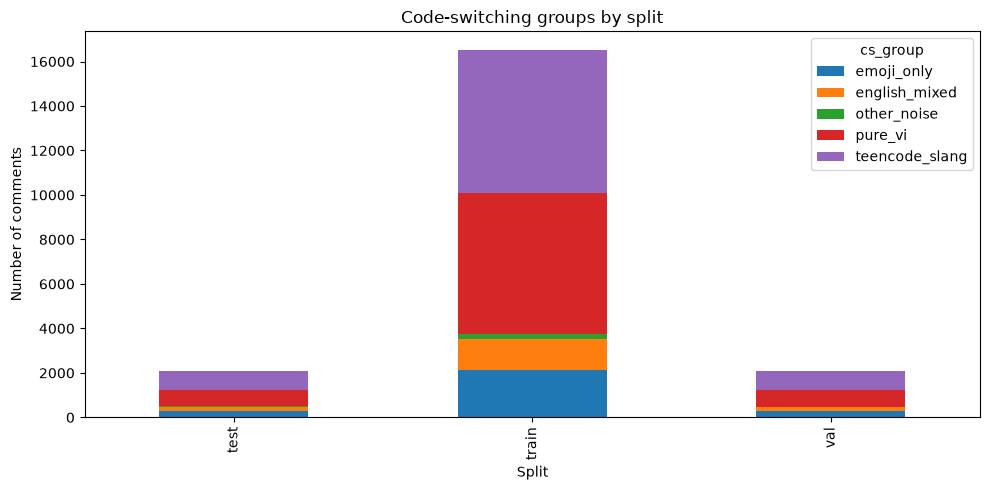

In [8]:
group_counts = pd.crosstab(analysis_df['split'], analysis_df['cs_group'], margins=True)
display(group_counts)
group_counts.to_csv(os.path.join(OUT_DIR, 'cs_group_by_split.csv'))

ax = group_counts.drop(index='All', errors='ignore').drop(columns='All', errors='ignore').plot(kind='bar', stacked=True, figsize=(10, 5))
ax.set_title('Code-switching groups by split')
ax.set_xlabel('Split')
ax.set_ylabel('Number of comments')
plt.tight_layout()
plt.show()

## 4. Top English/teencode tokens

In [9]:
def split_token_string(s):
    if pd.isna(s) or not str(s).strip():
        return []
    return [x.strip().lower() for x in str(s).split(',') if x.strip()]

english_counter = Counter(tok for s in analysis_df['english_tokens'] for tok in split_token_string(s))
teencode_counter = Counter(tok for s in analysis_df['teencode_tokens'] for tok in split_token_string(s))

top_english = pd.DataFrame(english_counter.most_common(50), columns=['token', 'count'])
top_teencode = pd.DataFrame(teencode_counter.most_common(50), columns=['token', 'count'])

display(top_english.head(30))
display(top_teencode.head(30))

top_english.to_csv(os.path.join(OUT_DIR, 'top_english_tokens.csv'), index=False)
top_teencode.to_csv(os.path.join(OUT_DIR, 'top_teencode_tokens.csv'), index=False)


,token,count
0,per,652
1,video,545
2,clip,74
3,july,38
4,comment,34
5,bro,32
6,game,30
7,like,29
8,fan,29
9,sorry,22


,token,count
0,mình,2907
1,cũng,2270
2,quá,1848
3,ko,1618
4,với,1147
5,k,1053
6,chứ,839
7,đc,598
8,vãi,452
9,v,300


## 5. Phân bố code-switching theo label

Nếu `labels` đang là số, bảng sẽ theo id label. Nếu muốn tên label, nạp thêm `label_dict.json` và map lại.

In [10]:
exploded = analysis_df.explode('label_list').copy()
exploded['label_list'] = exploded['label_list'].astype(str)

label_cs = (
    exploded.groupby('label_list')
    .agg(
        n=('text', 'size'),
        code_switched=('is_code_switched', 'sum'),
        english_mixed=('has_english', 'sum'),
        teencode_slang=('has_teencode', 'sum'),
    )
    .reset_index()
)
label_cs['code_switched_pct'] = label_cs['code_switched'] / label_cs['n'] * 100
label_cs = label_cs.sort_values(['code_switched_pct', 'n'], ascending=[False, False])

display(label_cs.head(40))
label_cs.to_csv(os.path.join(OUT_DIR, 'code_switching_by_label.csv'), index=False)


,label_list,n,code_switched,english_mixed,teencode_slang,code_switched_pct
9,17,933,596,62,572,63.879957
11,19,1129,690,50,664,61.116032
2,10,753,450,144,389,59.760956
8,16,960,558,75,525,58.125000
10,18,890,511,43,496,57.415730
23,5,1310,732,147,658,55.877863
4,12,879,481,84,451,54.721274
18,25,3336,1802,264,1686,54.016787
19,26,1204,649,78,608,53.903654
14,21,3484,1861,189,1782,53.415614


## 6. Lấy mẫu để kiểm tra thủ công

Bước này quan trọng: rule-based detector có thể sai. Bạn nên kiểm tra khoảng 50-100 mẫu để điều chỉnh `EN_COMMON`, `VI_STOPWORDS_ASCII`, `TEENCODE`.

In [11]:
sample_cols = ['split', 'text', 'labels', 'cs_group', 'english_tokens', 'teencode_tokens', 'emoji_count']

for group in ['english_mixed', 'teencode_slang', 'emoji_only', 'pure_vi']:
    print('\n###', group)
    display(
        analysis_df[analysis_df['cs_group'] == group][sample_cols]
        .sample(min(10, (analysis_df['cs_group'] == group).sum()), random_state=42)
    )

manual_parts = []
for _, group_df in analysis_df.groupby('cs_group'):
    manual_parts.append(group_df.sample(min(30, len(group_df)), random_state=42))
manual_sample = pd.concat(manual_parts, ignore_index=True)[sample_cols]
manual_sample.to_csv(os.path.join(OUT_DIR, 'manual_check_samples.csv'), index=False)
print('Saved:', os.path.join(OUT_DIR, 'manual_check_samples.csv'))


### english_mixed


,split,text,labels,cs_group,english_tokens,teencode_tokens,emoji_count
3609,train,per bảo này mày không được đi chơi đêm nhé,"[25, 26]",english_mixed,per,,0
4743,train,per dume vỉa hè quá rộng . con này không đi oto bao giờ là chắc ?,"[25, 24]",english_mixed,per,quá,0
4712,train,xem video của bạn thì mình xác nhận việc học quan trọng thế nào,"[12, 11]",english_mixed,video,mình,0
5357,train,per tao tán sấp mặt,[24],english_mixed,per,,0
18241,val,per mốt đừg có thiết kế hay xây mấy cái kiểu như dị nhé hem ><,"[12, 17]",english_mixed,per,hem,0
18926,test,per mày cũng có tình yêu từ nơi đây phải không ?,"[3, 14]",english_mixed,per,cũng,0
17031,val,"per thế là 2 anh này chưa gặp tao rồi , =)) 7km nhé","[0, 1]",english_mixed,per,,0
9585,train,"per mày ơi trò này lợi hại nè áp dụng ngay :"")))","[0, 1]",english_mixed,per,,0
19701,test,vận may s cứ xua đuổi mình hoài chứ có bao giờ tự tìm đến đâu ? đen thôi chứ đỏ quên điii nha . đời thường giết chết kẻ mộng mer như mình .,[25],english_mixed,mer,"mình, chứ, chứ, mình",0
13254,train,"Rất ủng hộ chủ đề này. Hiện nay team khát nước ra sức nói láo về lịch sử, kích động chia rẻ. Cần có tiếng nói đủ trọng lượng giàu tính giáo dục để ngăn chặn...","[11, 24, 26]",english_mixed,"team, fake",,0



### teencode_slang


,split,text,labels,cs_group,english_tokens,teencode_tokens,emoji_count
6963,train,Tại chính bản thân mình quá tin tưởng vào tình cảm để giờ bị tổn thương và tổn thất tư tinh thần đến vật chất. Thôi cố lên,"[18, 22, 21]",teencode_slang,,"mình, quá",0
15932,train,"Mình cũng đã có lúc như em trai này...gọi là lụy tình, đau khổ, buồn bã còn nghĩ đến tự hại bản thân, kì thực, họ đã ko yêu họ éo quan tâm đâu...khuyên thật...","[18, 5]",teencode_slang,,"mình, cũng, ko, đc, cũng",0
11090,train,hic không phải tiền của mình nên có vẻ nhiều người xem nhẹ quá nhỉ . 580k to mà công sức các thứ các thứ của chủ thớt chứ có đi xin đâu ? :)),[25],teencode_slang,,"mình, quá, k, chứ",0
2884,train,Chúc mừng GĐ đã gặp đc những bs có tâm có tầm,"[8, 9, 2]",teencode_slang,,đc,0
12647,train,em tâm đắc nhất với ý cuối cùng của chị : bớt đổ lỗi và chịu trách nhiệm với chính mình! thật khó để nhận ra khi bao lâu nay em thường đổ lỗi cho những ngườ...,"[9, 11]",teencode_slang,,"với, với, mình, mình, với",0
2086,train,V đến kỳ dâu thì phải lms,[14],teencode_slang,,v,0
14548,train,Tự hào khi mình được sinh ra ơi Việt Nam❤️🌻,"[7, 3]",teencode_slang,,mình,2
13349,train,Moi chuyen dk sắp đặt cả rồi ko việc gì phải hối hận cả 😊,"[5, 10]",teencode_slang,,"dk, ko",1
1139,train,Phim gì vậy mn,[14],teencode_slang,,mn,0
5810,train,con trai giờ mất giá v luôn hã mấy chế :))),[0],teencode_slang,,v,0



### emoji_only


,split,text,labels,cs_group,english_tokens,teencode_tokens,emoji_count
10548,train,môi thâm tự ti ác luôn 🙃,"[21, 19]",emoji_only,,,1
9542,train,tự là là người mang dòng máu Việt Nam🥰,"[3, 7]",emoji_only,,,1
8649,train,vừa sếp vừa đồng nghiệp tốt thì đi làm như là đi chơi 💃 bonus 6h chưa hẳn đã muốn về,"[0, 2, 1]",emoji_only,,,1
6359,train,10đ thế mới là người Việt nam 🥰🥰🥰,"[3, 7]",emoji_only,,,1
9596,train,😑 sao cái kết gì mà buồn vậy,"[20, 21]",emoji_only,,,1
4426,train,Em thật sự biết ơn anh rất rất nhiều. Một người thầy tuyệt vời ❤❤❤,"[9, 8]",emoji_only,,,1
6637,train,@Kỹ thuật và đời sống đoán vội chắc 18 🥰,[0],emoji_only,,,1
7842,train,"Em thích tất cả các chủ đề mà anh chia sẻ từ kinh tế, tài chính cho đến sức khỏe đời sống và tư duy góc nhìn. Chúc anh có nhiều sức khỏe, niềm vui và hạnh p...","[11, 6]",emoji_only,,,1
12712,train,miền tây tôi đấy 🥰,"[3, 7]",emoji_only,,,1
5434,train,Nguyễn Hoàn ok vào tù bú fame luôn a 🤣🤣🤣,[0],emoji_only,,,1



### pure_vi


,split,text,labels,cs_group,english_tokens,teencode_tokens,emoji_count
15080,train,con mụ đen sai còn già mồm ...,"[26, 23]",pure_vi,,,0
19533,test,đấy thấy chưa con người ta khổ như thế,"[20, 21]",pure_vi,,,0
15952,train,tôi rất tự hào vì mk là người Việt Nam 'TÔI YÊU VIỆT NAM'🇻🇳🇻🇳🇻🇳,"[7, 3]",pure_vi,,,0
1548,train,"Linh Phan ai đụng đến danh lam thắng cảnh PY tui ra đó nằm ăn vạ luôn,bạn khỏi phải lo.","[24, 25]",pure_vi,,,0
12019,train,Thơ củ chuối,"[26, 23]",pure_vi,,,0
20589,test,biết nấu cơm bếp củi từ lớp 2_3 gì đó,[7],pure_vi,,,0
3317,train,"chỉ có bọn nông dân mới nghĩ ra mấy trò này , phải con cháu nhà tao thì tao đến từng nhà 1 bắt từng thằng ăn cứt","[24, 23]",pure_vi,,,0
2126,train,Tự hào,[7],pure_vi,,,0
17601,val,Nang Mai í nói ít người cao thường thường 1m75.chưa thấy ai 1m8,[27],pure_vi,,,0
15693,train,"Vậy mà vẫn đứng xem tụi nhỏ biểu diễn rồi tung hô, còn ngăn cản công an nữa, đến lạy, ngu xuẩn, thật ngu xuẩn",[24],pure_vi,,,0


Saved: outputs_code_switching/manual_check_samples.csv


## 7. Gợi ý dùng kết quả cho thí nghiệm model

Sau khi chạy notebook này, dùng `vigo_code_switching_annotations.csv` để evaluate model theo subset:

- `all`: toàn bộ test set.
- `pure_vi`: `cs_group == 'pure_vi'`.
- `code_switched`: `is_code_switched == True`.
- `english_mixed`: `cs_group == 'english_mixed'`.
- `teencode_slang`: `cs_group == 'teencode_slang'`.

Bảng nên báo cáo trong luận văn:

| Model | All Macro F1 | Pure VI Macro F1 | Code-switched Macro F1 | English-mixed Macro F1 | Teencode Macro F1 |
|---|---:|---:|---:|---:|---:|
| XLM-R | | | | | |
| PhoBERT | | | | | |
| XLM-R + xLSTM | | | | | |
| PhoBERT + xLSTM | | | | | |
